<a href="https://colab.research.google.com/github/GiteshWagh/MathsPoster/blob/main/AMT_Poster_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Problem statement: Analyze the relationship between Air Quality Index (AQI) and hospital 
admissions for respiratory cases. The goal is to identify patterns, correlations between 
pollutants (PM2.5, NO2, O3), and predict hospital admission trends based on environmental factors.


--- Dataset Overview ---
Total Number Of Elements : 1061868

The Description of the dataset :
                       date           aqi         pm2_5          pm10  \
count                88489  88489.000000  88489.000000  88489.000000   
mean   2141-02-19 00:00:00    249.370182     35.144951     50.118654   
min    2020-01-01 00:00:00      0.000000      0.000000      0.000000   
25%    2080-07-26 00:00:00    124.000000     24.900000     36.600000   
50%    2141-02-19 00:00:00    249.000000     35.100000     50.000000   
75%    2201-09-15 00:00:00    374.000000     45.200000     63.500000   
max    2262-04-10 00:00:00    499.000000    109.900000    143.500000   
std                    NaN    144.479132     14

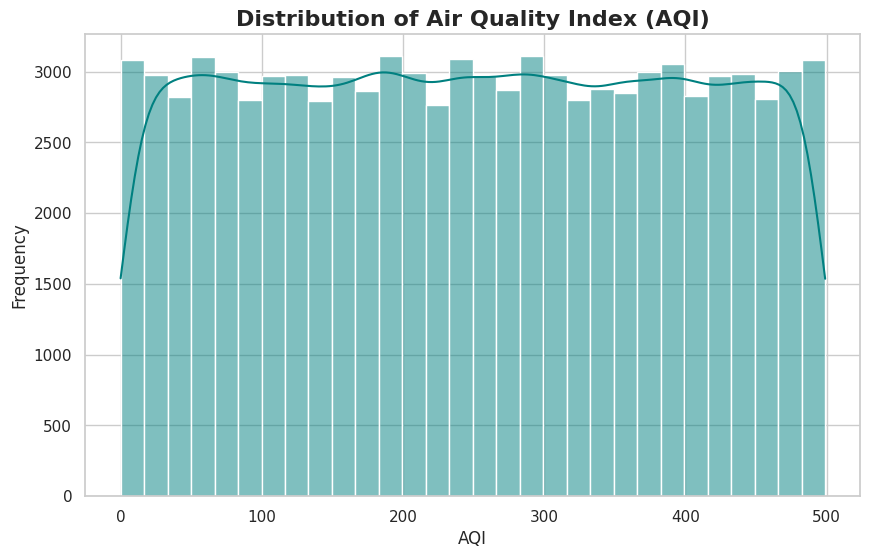

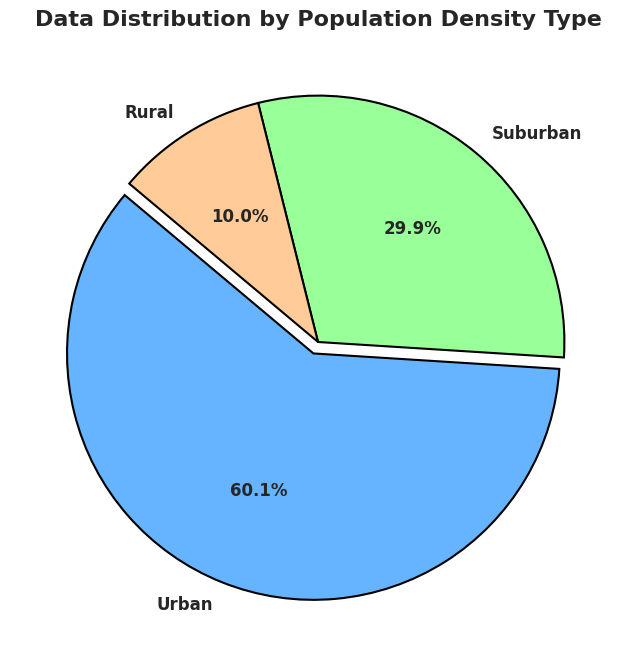

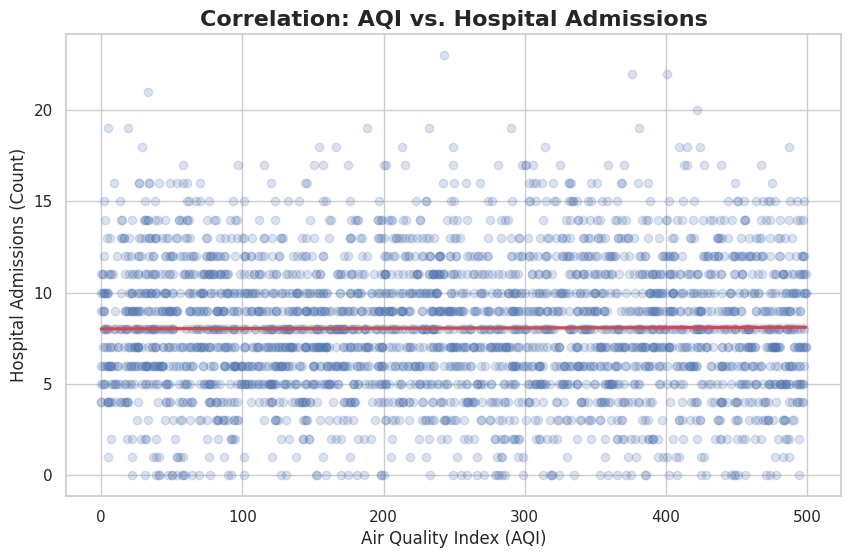

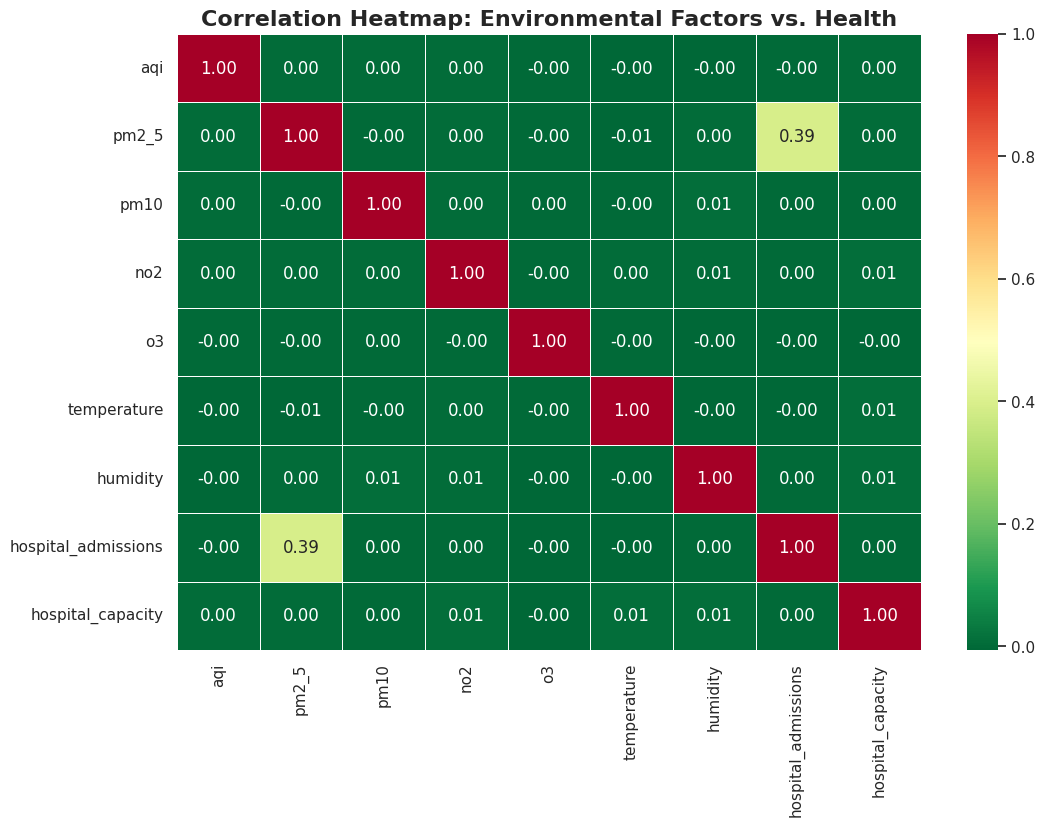

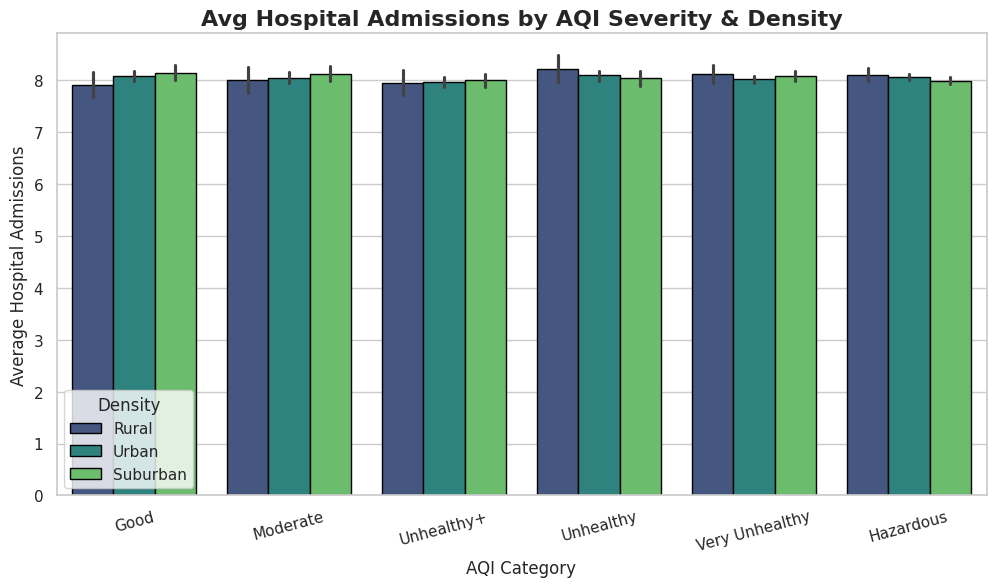

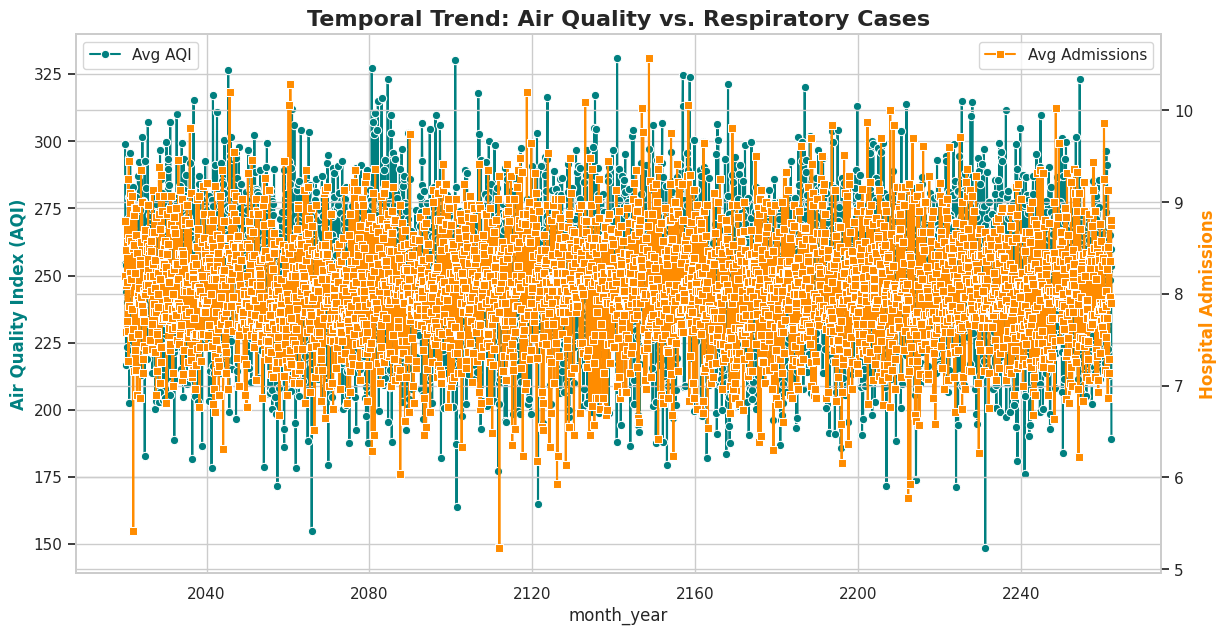

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for a professional look
sns.set_theme(style="whitegrid")

# Load the dataset
# File: air_quality_health_dataset.csv
df = pd.read_csv('air_quality_health_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

print("""
Problem statement: Analyze the relationship between Air Quality Index (AQI) and hospital
admissions for respiratory cases. The goal is to identify patterns, correlations between
pollutants (PM2.5, NO2, O3), and predict hospital admission trends based on environmental factors.
""")

# --------------------------------------------------------------
# Understanding The Dataset and Pre-processing
print("\n--- Dataset Overview ---")
print("Total Number Of Elements :", df.size)
print("\nThe Description of the dataset :\n", df.describe())

print("\nThe features of our dataset:")
for col in df.columns:
    print(f"- {col}")

# --------------------------------------------------------------
# Data Cleaning
print("\n--- Data Cleaning ---")
print("Missing values per column:\n", df.isnull().sum())
df.drop_duplicates(inplace=True)
print("Duplicate data removed. Final shape:", df.shape)

# --------------------------------------------------------------
# 1. AQI Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['aqi'], kde=True, color='teal', bins=30)
plt.title("Distribution of Air Quality Index (AQI)", fontsize=16, fontweight='bold')
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.savefig('aqi_distribution.png')

# --------------------------------------------------------------
# 2. Population Density Distribution (Pie Chart)
density_counts = df['population_density'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(density_counts, labels=density_counts.index, autopct='%1.1f%%', startangle=140,
        colors=['#66b3ff','#99ff99','#ffcc99'], explode=(0.05, 0, 0),
        textprops={'fontsize':12,'weight':'bold'}, wedgeprops={'linewidth': 1.5, 'edgecolor': 'black'})
plt.title("Data Distribution by Population Density Type", fontsize=16, fontweight='bold')
plt.savefig('density_pie.png')

# --------------------------------------------------------------
# 3. AQI vs Hospital Admissions (Regression Plot)
plt.figure(figsize=(10, 6))
# Sampling data for a clearer visual representation
sample_df = df.sample(n=min(len(df), 3000), random_state=42)
sns.regplot(x='aqi', y='hospital_admissions', data=sample_df,
            scatter_kws={'alpha':0.2, 'color':'#4C72B0'}, line_kws={'color':'#C44E52'})
plt.title("Correlation: AQI vs. Hospital Admissions", fontsize=16, fontweight='bold')
plt.xlabel("Air Quality Index (AQI)")
plt.ylabel("Hospital Admissions (Count)")
plt.savefig('aqi_vs_admissions.png')

# --------------------------------------------------------------
# 4. Correlation Heatmap (Pollutants & Health)
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn_r', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Environmental Factors vs. Health", fontsize=16, fontweight='bold')
plt.savefig('correlation_heatmap.png')

# --------------------------------------------------------------
# 5. Admissions by AQI Severity & Density (Bar Chart)
# Creating AQI Categories based on standard scales
df['AQI_Category'] = pd.cut(df['aqi'], bins=[0, 50, 100, 150, 200, 300, 500],
                            labels=['Good', 'Moderate', 'Unhealthy+', 'Unhealthy', 'Very Unhealthy', 'Hazardous'])

plt.figure(figsize=(12, 6))
sns.barplot(x='AQI_Category', y='hospital_admissions', hue='population_density', data=df, palette='viridis', edgecolor='black')
plt.title("Avg Hospital Admissions by AQI Severity & Density", fontsize=16, fontweight='bold')
plt.xlabel("AQI Category")
plt.ylabel("Average Hospital Admissions")
plt.xticks(rotation=15)
plt.legend(title='Density')
plt.savefig('admissions_by_aqi_cat.png')

# --------------------------------------------------------------
# 6. Temporal Trends (Monthly Line Chart)
df['month_year'] = df['date'].dt.to_period('M')
monthly_trend = df.groupby('month_year')[['aqi', 'hospital_admissions']].mean()
monthly_trend.index = monthly_trend.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='aqi', ax=ax1, color='teal', marker='o', label='Avg AQI')
sns.lineplot(data=monthly_trend, x=monthly_trend.index, y='hospital_admissions', ax=ax2, color='darkorange', marker='s', label='Avg Admissions')

ax1.set_ylabel('Air Quality Index (AQI)', color='teal', fontsize=12, fontweight='bold')
ax2.set_ylabel('Hospital Admissions', color='darkorange', fontsize=12, fontweight='bold')
plt.title("Temporal Trend: Air Quality vs. Respiratory Cases", fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.savefig('temporal_trend.png')

plt.show()

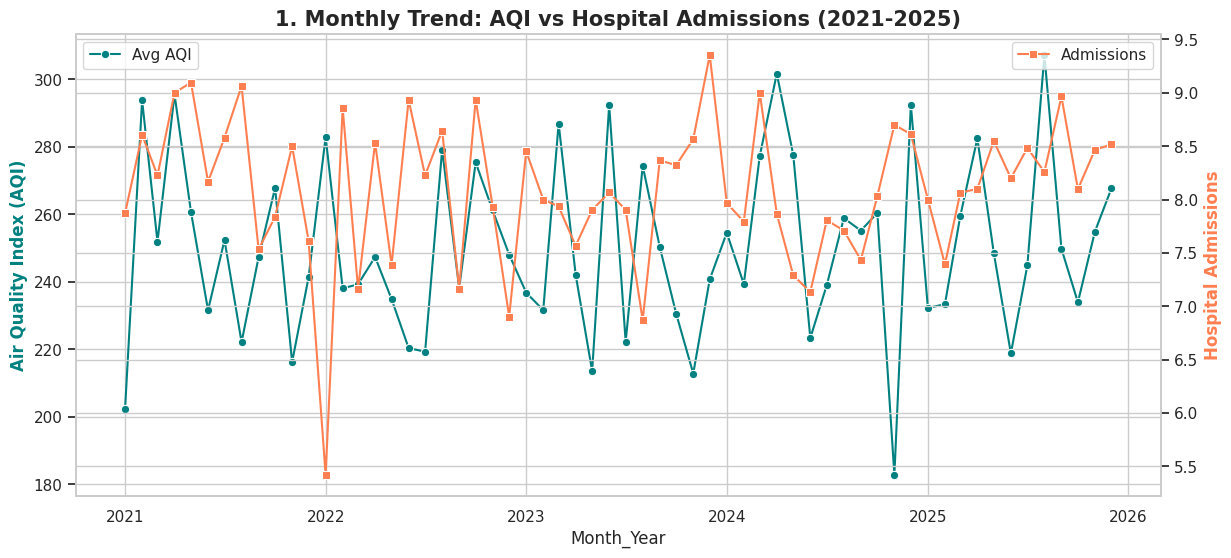

/tmp/ipykernel_2659/3701554254.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AQI_Category', y='hospital_admissions', data=df, palette='YlOrRd', edgecolor='black')


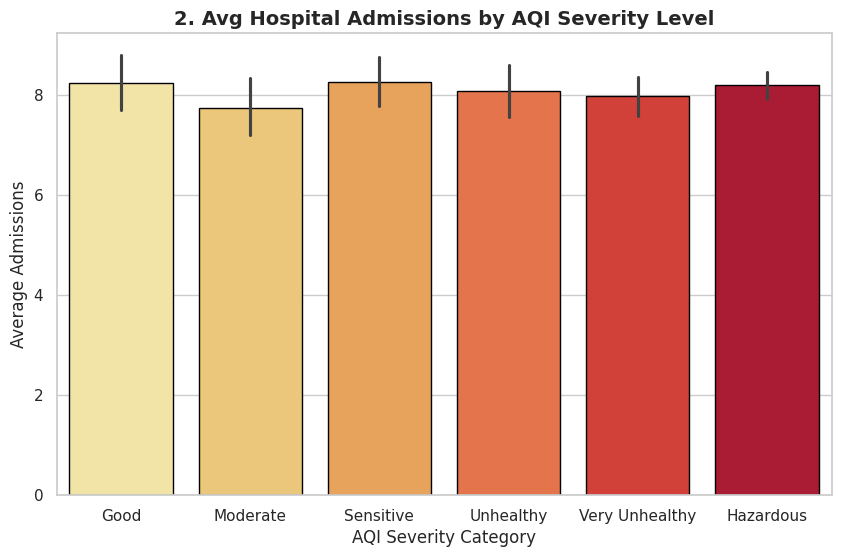

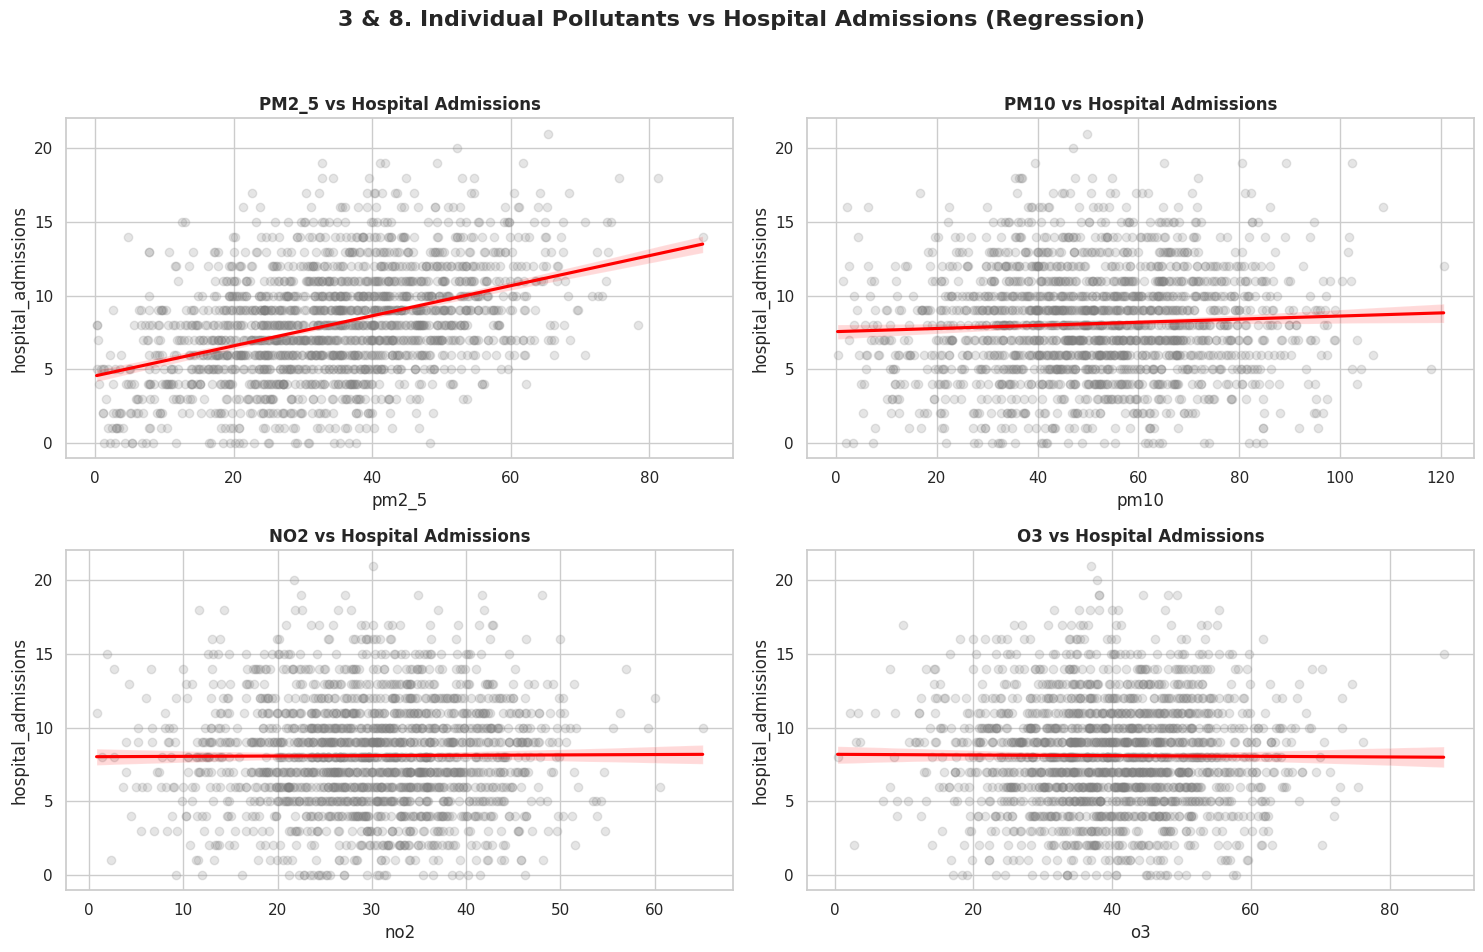

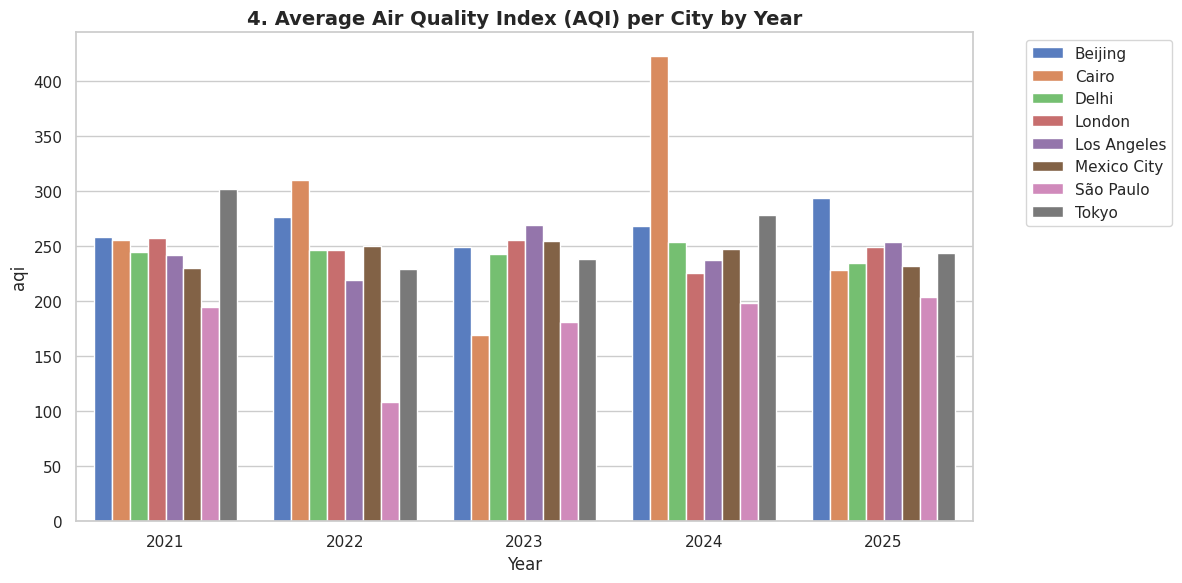

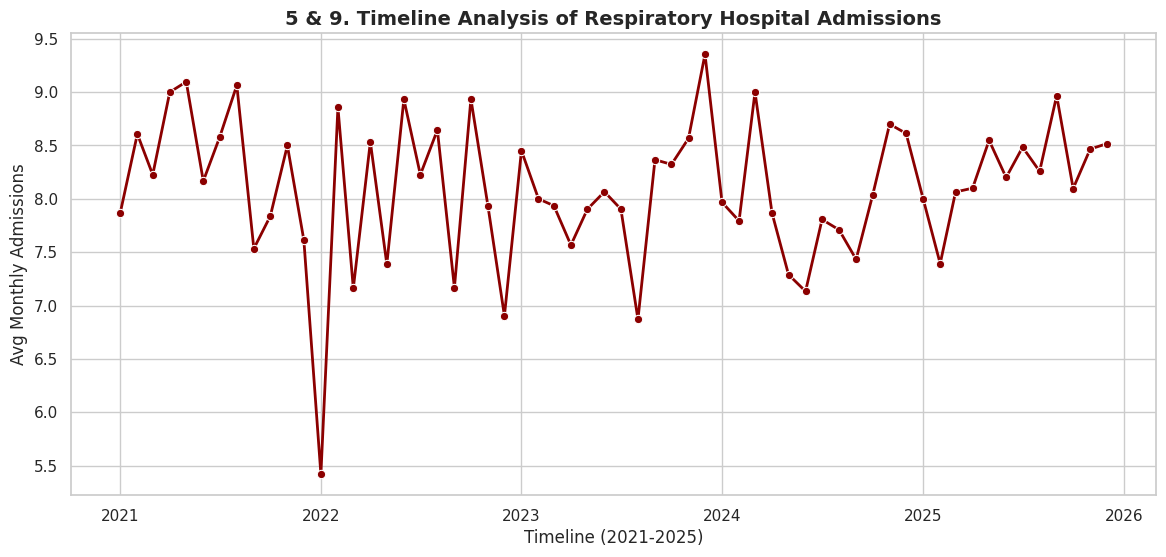

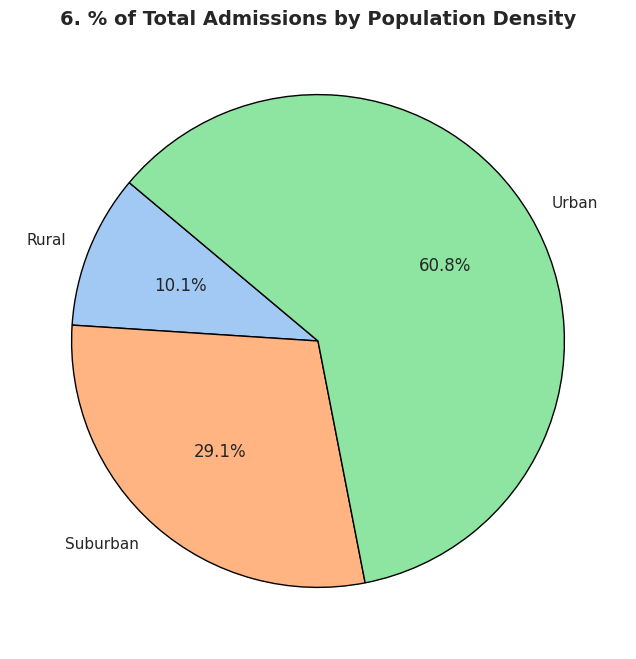

/tmp/ipykernel_2659/3701554254.py:96: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='city', y='hospital_admissions', data=df, palette='coolwarm', edgecolor='black', ci=None)
/tmp/ipykernel_2659/3701554254.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='hospital_admissions', data=df, palette='coolwarm', edgecolor='black', ci=None)


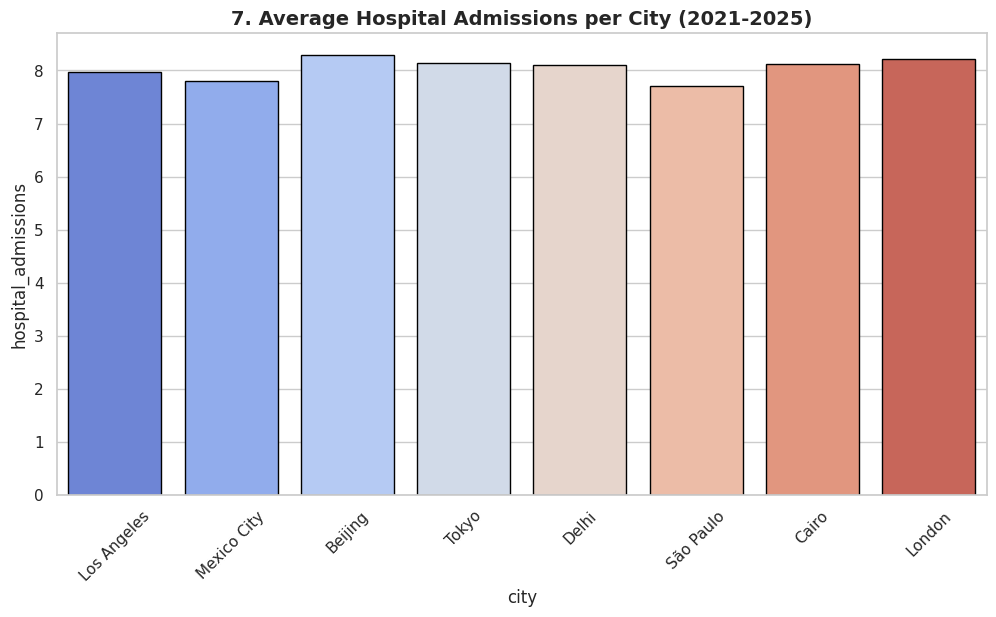

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visualization style
sns.set_theme(style="whitegrid")

# 1. LOAD AND PRE-PROCESS DATA
# --------------------------------------------------------------
df = pd.read_csv('air_quality_health_dataset.csv')
df['date'] = pd.to_datetime(df['date'])

# FILTER DATA FOR 2021-2025
df = df[(df['date'].dt.year >= 2021) & (df['date'].dt.year <= 2025)].copy()

# Add Helper Columns for Analysis
# AQI Bins for Severity Analysis
bins = [0, 50, 100, 150, 200, 300, 500]
labels = ['Good', 'Moderate', 'Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
df['AQI_Category'] = pd.cut(df['aqi'], bins=bins, labels=labels)

# Time components
df['Year'] = df['date'].dt.year
df['Month_Year'] = df['date'].dt.to_period('M').dt.to_timestamp()

# 2. DATA ANALYSIS & VISUALIZATION
# --------------------------------------------------------------

# GRAPH 1: Dual-Axis Time Series (Monthly Trend)
# Variables: date (x), aqi (y1), hospital_admissions (y2)
plt.figure(figsize=(14, 6))
monthly_data = df.groupby('Month_Year')[['aqi', 'hospital_admissions']].mean().reset_index()
ax1 = plt.gca()
ax2 = ax1.twinx()
sns.lineplot(data=monthly_data, x='Month_Year', y='aqi', ax=ax1, color='teal', label='Avg AQI', marker='o')
sns.lineplot(data=monthly_data, x='Month_Year', y='hospital_admissions', ax=ax2, color='coral', label='Admissions', marker='s')
ax1.set_ylabel('Air Quality Index (AQI)', color='teal', fontweight='bold')
ax2.set_ylabel('Hospital Admissions', color='coral', fontweight='bold')
plt.title('1. Monthly Trend: AQI vs Hospital Admissions (2021-2025)', fontsize=15, fontweight='bold')
plt.show()

# GRAPH 2: Impact by AQI Severity (Binned Bar Chart)
# Variables: AQI_Category (x), hospital_admissions (y)
plt.figure(figsize=(10, 6))
sns.barplot(x='AQI_Category', y='hospital_admissions', data=df, palette='YlOrRd', edgecolor='black')
plt.title('2. Avg Hospital Admissions by AQI Severity Level', fontsize=14, fontweight='bold')
plt.xlabel('AQI Severity Category')
plt.ylabel('Average Admissions')
plt.show()

# GRAPH 3 & 8: Multi-Pollutant & Individual Pollutant Regression Analysis
# Variables: Pollutants (PM2.5, NO2, etc.) vs hospital_admissions
pollutants = ['pm2_5', 'pm10', 'no2', 'o3']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, pol in enumerate(pollutants):
    sns.regplot(data=df.sample(min(2000, len(df))), x=pol, y='hospital_admissions', ax=axes[i],
                scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'red'})
    axes[i].set_title(f'{pol.upper()} vs Hospital Admissions', fontweight='bold')
plt.suptitle('3 & 8. Individual Pollutants vs Hospital Admissions (Regression)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# GRAPH 4: AQI VS YEAR OF THE CITIES
# Variables: Year (x), AQI (y), City (hue)
plt.figure(figsize=(12, 6))
city_year_aqi = df.groupby(['city', 'Year'])['aqi'].mean().reset_index()
sns.barplot(data=city_year_aqi, x='Year', y='aqi', hue='city', palette='muted')
plt.title('4. Average Air Quality Index (AQI) per City by Year', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# GRAPH 5 & 9: HOSPITAL ADMISSIONS VS MONTH/YEAR (Timeline)
# Variables: Timeline (x), Hospital Admissions (y)
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_data, x='Month_Year', y='hospital_admissions', color='darkred', linewidth=2, marker='o')
plt.title('5 & 9. Timeline Analysis of Respiratory Hospital Admissions', fontsize=14, fontweight='bold')
plt.xlabel('Timeline (2021-2025)')
plt.ylabel('Avg Monthly Admissions')
plt.show()

# GRAPH 6: POPULATION DENSITY PIE CHART
# Variables: Population Density vs Hospital Admissions
plt.figure(figsize=(8, 8))
density_admissions = df.groupby('population_density')['hospital_admissions'].sum()
plt.pie(density_admissions, labels=density_admissions.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'), wedgeprops={'edgecolor':'black'})
plt.title('6. % of Total Admissions by Population Density', fontsize=14, fontweight='bold')
plt.show()

# GRAPH 7: CITIES VS HOSPITAL ADMISSIONS
# Variables: City (x), Hospital Admissions (y)
plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='hospital_admissions', data=df, palette='coolwarm', edgecolor='black', ci=None)
plt.title('7. Average Hospital Admissions per City (2021-2025)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global plotting style
sns.set_theme(style="whitegrid")

# 1. LOAD AND FILTER DATA (2021-2025)
# --------------------------------------------------------------
df = pd.read_csv('air_quality_health_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'].dt.year >= 2021) & (df['date'].dt.year <= 2025)].copy()

# Add Helper Columns
df['Year'] = df['date'].dt.year
df['Month_Year'] = df['date'].dt.to_period('M').dt.to_timestamp()

# Define AQI Categories
bins = [0, 50, 100, 150, 200, 300, 500]
labels = ['Good', 'Moderate', 'Sensitive', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
df['AQI_Category'] = pd.cut(df['aqi'], bins=bins, labels=labels)

# 2. UPDATED VISUALIZATIONS
# --------------------------------------------------------------

# GRAPH 1: Hospital Admissions Trends by City (Faceted Line Plots)
# This separates each city into its own chart to avoid a messy "spaghetti" plot.
g = sns.relplot(
    data=df.groupby(['Month_Year', 'city'])['hospital_admissions'].mean().reset_index(),
    x='Month_Year', y='hospital_admissions',
    col='city', col_wrap=3, kind='line',
    height=3, aspect=1.5, marker='o', color='darkred'
)
g.set_axis_labels("Timeline", "Avg Admissions")
g.fig.suptitle('1. Hospital Admission Trends per City (Individual Timelines)', fontsize=16, fontweight='bold', y=1.05)
plt.show()

# GRAPH 2: Year-wise Pie Charts (Distribution by Region)
# Shows the % of cases in Rural, Urban, and Suburban areas for each year.
years = sorted(df['Year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(25, 6))

for i, year in enumerate(years):
    year_data = df[df['Year'] == year]
    density_dist = year_data.groupby('population_density')['hospital_admissions'].sum()
    axes[i].pie(density_dist, labels=density_dist.index, autopct='%1.1f%%',
                startangle=140, colors=['#ff9999','#66b3ff','#99ff99'],
                wedgeprops={'edgecolor':'black', 'linewidth': 1.5})
    axes[i].set_title(f'Year {year}', fontsize=15, fontweight='bold')

plt.suptitle('2. Yearly Hospital Case Distribution: Rural vs Urban vs Suburban', fontsize=20, fontweight='bold', y=1.1)
plt.show()

# GRAPH 3: Pollutant Impact Trend Analysis
# Replacing scatter plots with clean trend lines showing how admissions rise with pollution.
pollutants = ['pm2_5', 'pm10', 'no2', 'o3']
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, pol in enumerate(pollutants):
    # Grouping pollutant values into 10 bins to show a clean trend
    df[f'{pol}_bin'] = pd.qcut(df[pol], q=10, duplicates='drop')
    trend = df.groupby(f'{pol}_bin', observed=True)['hospital_admissions'].mean().reset_index()
    trend['bin_center'] = trend[f'{pol}_bin'].apply(lambda x: x.mid)

    sns.lineplot(data=trend, x='bin_center', y='hospital_admissions', ax=axes[i],
                 marker='s', color='blue', linewidth=3)
    axes[i].set_title(f'{pol.upper()} Concentration vs Avg Admissions', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{pol.upper()} Levels')
    axes[i].set_ylabel('Avg Admissions')

plt.suptitle('3. Impact Analysis: How Specific Pollutants Affect Respiratory Admissions', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# GRAPH 4: Comparative Annual Admissions per City
plt.figure(figsize=(14, 6))
sns.barplot(x='city', y='hospital_admissions', hue='Year', data=df, palette='magma', ci=None, edgecolor='black')
plt.title('4. Annual Comparison of Admissions across Cities', fontsize=14, fontweight='bold')
plt.ylabel('Average Daily Admissions')
plt.xticks(rotation=45)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# GRAPH 5: AQI Severity Impact
plt.figure(figsize=(10, 6))
sns.barplot(x='AQI_Category', y='hospital_admissions', data=df, palette='Reds', edgecolor='black', ci=None)
plt.title('5. Impact of AQI Severity on Respiratory Admissions (2021-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Average Admissions')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization theme
sns.set_theme(style="whitegrid")

# 1. LOAD AND FILTER DATA (2021-2025)
# --------------------------------------------------------------
df = pd.read_csv('air_quality_health_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'].dt.year >= 2021) & (df['date'].dt.year <= 2025)].copy()
df['Year'] = df['date'].dt.year

# 2. POPULATION DENSITY VS HOSPITAL ADMISSIONS ANALYSIS
# --------------------------------------------------------------

# GRAPH A: Average Admissions by Population Density (Comparative Bar Chart)
plt.figure(figsize=(10, 6))
sns.barplot(x='population_density', y='hospital_admissions', data=df, palette='Set2', ci=None, edgecolor='black')
plt.title('A. Average Hospital Admissions by Population Density (2021-2025)', fontsize=15, fontweight='bold')
plt.xlabel('Population Density Type (Urban, Suburban, Rural)')
plt.ylabel('Average Admissions per Day')
plt.show()

# GRAPH B: Year-wise Average Admissions by Region (Using HUE)
# This shows if the average number of cases is increasing year-over-year in each region
plt.figure(figsize=(12, 6))
sns.barplot(x='population_density', y='hospital_admissions', hue='Year', data=df, palette='viridis', ci=None, edgecolor='black')
plt.title('B. Year-Wise Comparison of Average Admissions by Region', fontsize=15, fontweight='bold')
plt.xlabel('Population Density Type')
plt.ylabel('Average Admissions')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# GRAPH C: Distribution and Outliers (Box Plot)
# Useful for seeing the range of cases (Min, Max, and Median)
plt.figure(figsize=(10, 6))
sns.boxplot(x='population_density', y='hospital_admissions', data=df, palette='Pastel1')
plt.title('C. Spread of Hospital Admissions across Regions', fontsize=15, fontweight='bold')
plt.xlabel('Region Type')
plt.ylabel('Number of Admissions (Daily)')
plt.show()

# GRAPH D: Year-wise Total Distribution (Requested Pie Charts)
# Shows the % share of total cases for Rural, Urban, and Suburban regions per year
years = sorted(df['Year'].unique())
fig, axes = plt.subplots(1, len(years), figsize=(25, 6))

for i, year in enumerate(years):
    year_data = df[df['Year'] == year]
    # Summing up total admissions per density for that year
    density_total = year_data.groupby('population_density')['hospital_admissions'].sum()

    axes[i].pie(density_total, labels=density_total.index, autopct='%1.1f%%',
                startangle=140, colors=['#ff9999','#66b3ff','#99ff99'],
                wedgeprops={'edgecolor':'black', 'linewidth': 1.2})
    axes[i].set_title(f'Total Cases in {year}', fontsize=16, fontweight='bold')

plt.suptitle('D. Yearly Share of Hospital Admissions by Region Type', fontsize=22, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

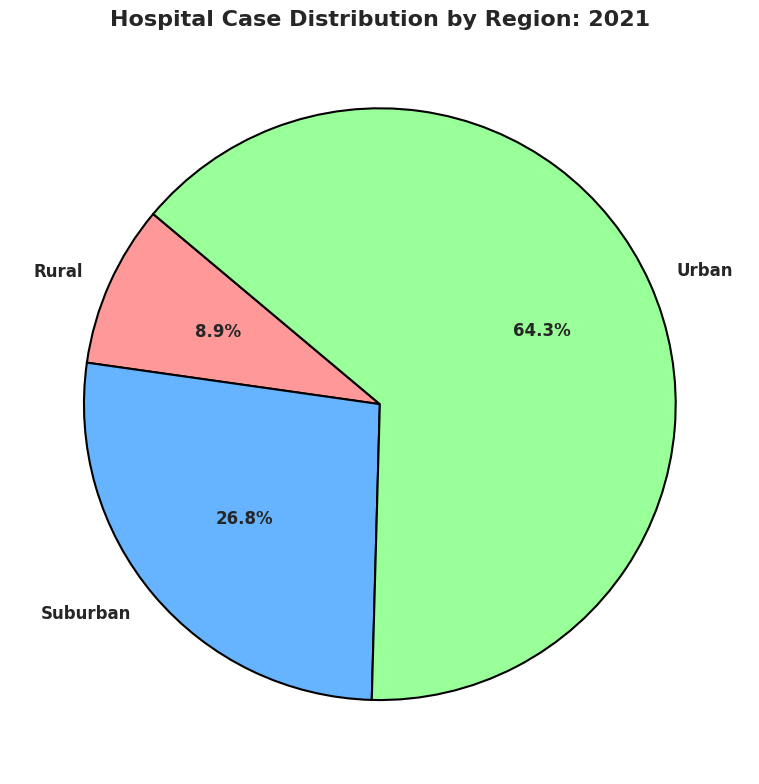

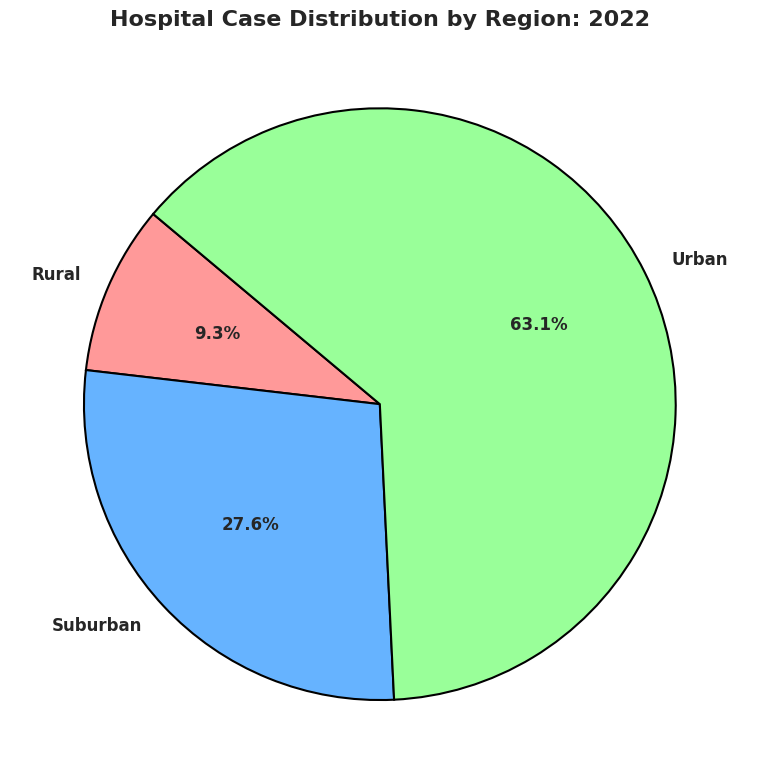

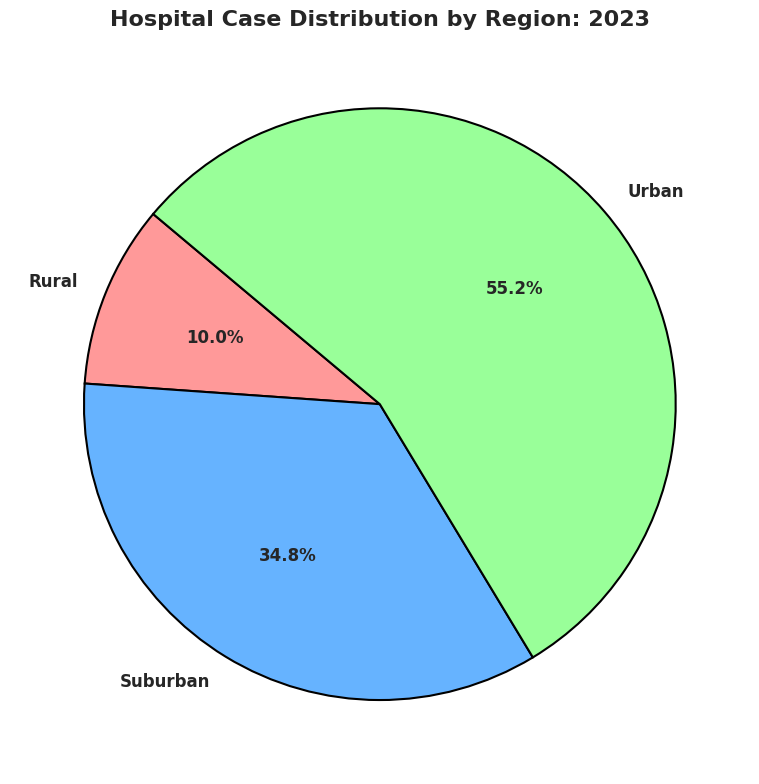

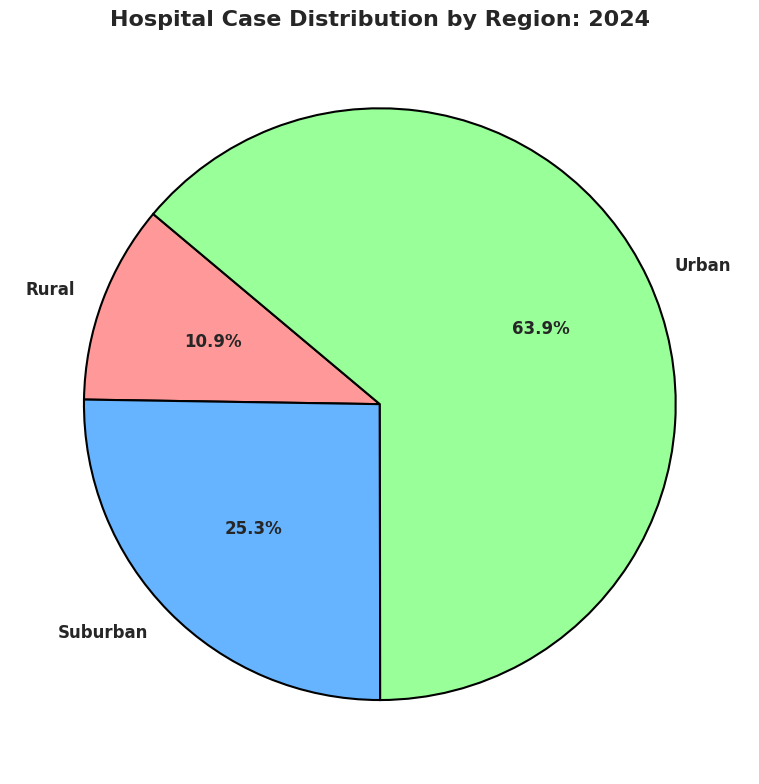

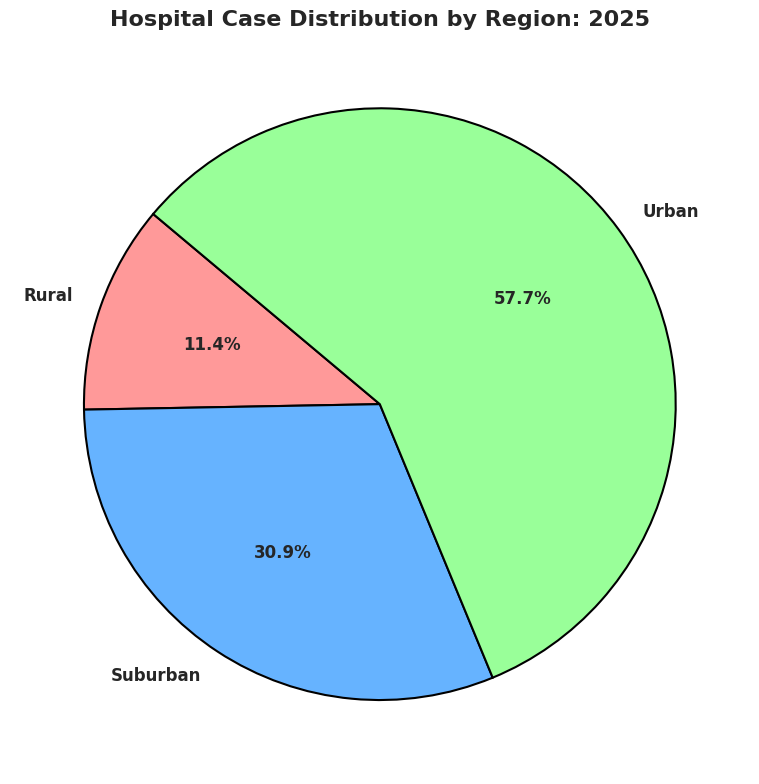

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. LOAD AND FILTER DATA (2021-2025)
# --------------------------------------------------------------
df = pd.read_csv('air_quality_health_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'].dt.year >= 2021) & (df['date'].dt.year <= 2025)].copy()
df['Year'] = df['date'].dt.year

# 2. GENERATE SEPARATE PIE CHARTS
# --------------------------------------------------------------
years = sorted(df['Year'].unique())
colors = ['#ff9999','#66b3ff','#99ff99'] # Colors for Rural, Urban, Suburban

for year in years:
    plt.figure(figsize=(8, 8))

    # Filter data for the specific year
    year_data = df[df['Year'] == year]
    density_dist = year_data.groupby('population_density')['hospital_admissions'].sum()

    # Plotting
    plt.pie(density_dist,
            labels=density_dist.index,
            autopct='%1.1f%%',
            startangle=140,
            colors=colors,
            wedgeprops={'edgecolor':'black', 'linewidth': 1.5},
            textprops={'fontsize': 12, 'weight': 'bold'})

    plt.title(f'Hospital Case Distribution by Region: {year}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show() # This displays each year one by one

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. LOAD AND FILTER DATA (2021-2025)
# --------------------------------------------------------------
df = pd.read_csv('air_quality_health_dataset.csv')
df['date'] = pd.to_datetime(df['date'])
mask = (df['date'].dt.year >= 2021) & (df['date'].dt.year <= 2025)
df_total = df[mask].copy()

# 2. GENERATE OVERALL PIE CHART
# --------------------------------------------------------------
plt.figure(figsize=(10, 10))

# Group by density and sum the admissions
overall_dist = df_total.groupby('population_density')['hospital_admissions'].sum()

# Define specific colors for consistency
colors = ['#ff9999', '#66b3ff', '#99ff99'] # Rural, Urban, Suburban

plt.pie(overall_dist,
        labels=overall_dist.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0.05, 0.05), # Slightly separate all slices for emphasis
        wedgeprops={'edgecolor':'black', 'linewidth': 2},
        textprops={'fontsize': 14, 'weight': 'bold'})

plt.title('Overall Hospital Case Distribution by Region (2021-2025)', fontsize=18, fontweight='bold')
plt.annotate('Total Aggregate Data', xy=(0.8, -0.9), fontsize=12, fontstyle='italic')

plt.tight_layout()
plt.show()